# 🔋Predicting Battery Degradation Through Cycling Data🔋

## Contributions
This is a solo project done by Lixin Nie


## Introduction

Lithium-ion batteries are widely used in modern applications, including consumer electronics, electric vehicles, and energy storage systems. A key challenge in their usage is performance degradation over time, which affects capacity, efficiency, and overall lifespan.

In this project, we analyze battery cycling data to better understand charge and discharge behavior and prepare the data for future degradation modeling. The dataset used comes from experimental battery tests and includes measurements such as voltage, current, temperature, and cycle-related information over time.

The goal of this notebook is to:
- Load and inspect the raw battery dataset
- Clean and preprocess the data for analysis
- Identify key features such as charge and discharge phases
- Prepare the dataset for further analysis, including cycle extraction and degradation modeling

By structuring and cleaning the data properly, we enable more meaningful analysis and modeling in later stages of the analysis.

# Data Pre-Processing

The data collection stage of the Data Science lifecycle involves gathering relevant data that will help answer our research questions. For this project, we used battery cycling data provided by the **Center for Advanced Life Cycle Engineering (CALCE)** at the University of Maryland, available at [https://calce.umd.edu/battery-data](https://calce.umd.edu/battery-data). CALCE provides open-access experimental data on lithium-ion battery performance, including continuous full and partial cycling, storage conditions, dynamic driving profiles, open-circuit voltage measurements, and impedance data. Battery form factors in the dataset include cylindrical, pouch, and prismatic cells.

The dataset includes high-resolution measurements such as voltage, current, capacity, temperature, and cycle count. These variables allow us to track how battery performance evolves over time and under repeated usage, which is critical for analyzing degradation patterns.

Since the data is collected and shared by a reputable research institution, it is considered reliable and suitable for scientific analysis. For this project, we selected a subset of the available cycling datasets that contain sufficient observations and relevant features for studying battery degradation. These datasets were then downloaded and prepared for further processing in the next stage of the data science lifecycle.

We are going to utulize Python modules such as **numpy**, **pandas**, and **matplotlib** were used to process, analyze, and visualize the data.

In [123]:
#importing the necessary packages
import numpy as np 
import glob
import pandas as pd
import matplotlib as plt
import matplotlib.pyplot as plt
from scipy import stats


The dataset is stored in a `.txt` file format. Unlike standard CSV files, this dataset uses a tab (`\t`) as the delimiter. Therefore, we must explicitly specify the separator when loading the data using pandas.

We load the dataset into a pandas DataFrame for further processing and analysis.

We first down load the CS2 dataset from CALCE, website and we imported the entire directory into our linux environment. 

<pre> (.venv) lixinnie@LIXINLAPTOP:~/CMSC320-Battery-Degradation-Prediction/CS2_8$ ls
CS2_8_1_19_10.txt  CS2_8_2_02_10.txt  CS2_8_4_5_10.txt   CS2_8_6_8_10.txt   CS2_8_7_9_10.txt   CS2_8_8_30_10.txt
CS2_8_1_20_10.txt  CS2_8_2_04_10.txt  CS2_8_4_8_10.txt   CS2_8_7_12_10.txt  CS2_8_8_10_10.txt  CS2_8_8_4_10.txt
CS2_8_1_26_10.txt  CS2_8_2_22_10.txt  CS2_8_5_11_10.txt  CS2_8_7_19_10.txt  CS2_8_8_12_10.txt  CS2_8_8_6_10.txt
CS2_8_1_27_10.txt  CS2_8_2_24_10.txt  CS2_8_5_14_10.txt  CS2_8_7_22_10.txt  CS2_8_8_13_10.txt  CS2_8_9_21_10.txt
CS2_8_1_28_10.txt  CS2_8_3_5_10.txt   CS2_8_6_1_10.txt   CS2_8_7_27_10.txt  CS2_8_8_19_10.txt  CS2_8_9_7_10.txt
CS2_8_1_29_10.txt  CS2_8_4_26_10.txt  CS2_8_6_7_10.txt   CS2_8_7_8_10.txt   CS2_8_8_23_10.txt </pre>

Notice that this entire datasets contains 35 files in it's entire series, so it's a good idea to analyze a few and figureout a way to combine them into a single dataframe. 
Let's begin with a quick preview of a single file. 

In [124]:
#We would need additional argument "sep="\t"" since the seperator is not comma in this case. 
df = pd.read_csv("./CS2_8/CS2_8_1_19_10.txt", sep="\t")


print("Shape of dataframe (rows, columns):")
print(df.shape)
print("\nColumn names:")
print(df.columns.tolist())
print("\nDataframe info:")
print(df.info())
print("\nPreview of dataframe:")
df.head()

Shape of dataframe (rows, columns):
(3268, 30)

Column names:
['Time', 'Status code', 'Status category', 'Status color', 'Pgm code', 'Pgm step', 'Pgm para', 'Pgm cycle', 'mV', 'mA', 'Temperature', 'Duration', 'Charge count', 'Discharge count', 'Capacity', 'Analog input 1', 'Analog input 2', 'Analog input 3', 'Analog input 4', 'Digital input 1', 'Digital input 2', 'Digital input 3', 'Digital input 4', 'Digital output 1', 'Digital output 2', 'Digital output 3', 'Digital output 4', 'Analog output 1', 'Analog output 2', 'Unnamed: 29']

Dataframe info:
<class 'pandas.DataFrame'>
RangeIndex: 3268 entries, 0 to 3267
Data columns (total 30 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Time              3268 non-null   float64
 1   Status code       3268 non-null   int64  
 2   Status category   3268 non-null   int64  
 3   Status color      3268 non-null   int64  
 4   Pgm code          3268 non-null   int64  
 5   Pgm step        

,Time,Status code,Status category,Status color,Pgm code,Pgm step,Pgm para,Pgm cycle,mV,mA,...,Digital input 2,Digital input 3,Digital input 4,Digital output 1,Digital output 2,Digital output 3,Digital output 4,Analog output 1,Analog output 2,Unnamed: 29
0,0.000000,8,3,3,0,1,2,2,4005,552,...,0,0,0,0,0,0,0,0,0,NaN
1,0.750233,8,3,3,0,1,2,2,4030,550,...,0,0,0,0,0,0,0,0,0,NaN
2,1.745283,8,3,3,0,1,2,2,4042,548,...,0,0,0,0,0,0,0,0,0,NaN
3,2.761917,8,3,3,0,1,2,2,4047,549,...,0,0,0,0,0,0,0,0,0,NaN
4,3.758400,8,3,3,0,1,2,2,4051,550,...,0,0,0,0,0,0,0,0,0,NaN


Now we have a rough idea of what a single file look like, lets combine them all into a single dataframe.

In [125]:
files = sorted(glob.glob('./CS2_8/CS2_8_*.txt'))
print(f"Found {len(files)} files")

dfs = []
for f in files:
    temp = pd.read_csv(f, sep='\t')
    temp = temp.drop(columns=temp.columns[temp.isnull().all()]) #Dropping the NaN columns before we combine
    temp.columns = temp.columns.str.strip()
    temp['source_file'] = f #We add a column to keep track of which file did the data come from.
    dfs.append(temp)

df = pd.concat(dfs, ignore_index=True)

print(f"Combined shape: {df.shape}")
display(df.head())

Found 35 files
Combined shape: (359794, 30)


,Time,Status code,Status category,Status color,Pgm code,Pgm step,Pgm para,Pgm cycle,mV,mA,...,Digital input 2,Digital input 3,Digital input 4,Digital output 1,Digital output 2,Digital output 3,Digital output 4,Analog output 1,Analog output 2,source_file
0,0.000000,8,3,3,0,1,2,2,4005,552,...,0,0,0,0,0,0,0,0,0,./CS2_8/CS2_8_1_19_10.txt
1,0.750233,8,3,3,0,1,2,2,4030,550,...,0,0,0,0,0,0,0,0,0,./CS2_8/CS2_8_1_19_10.txt
2,1.745283,8,3,3,0,1,2,2,4042,548,...,0,0,0,0,0,0,0,0,0,./CS2_8/CS2_8_1_19_10.txt
3,2.761917,8,3,3,0,1,2,2,4047,549,...,0,0,0,0,0,0,0,0,0,./CS2_8/CS2_8_1_19_10.txt
4,3.758400,8,3,3,0,1,2,2,4051,550,...,0,0,0,0,0,0,0,0,0,./CS2_8/CS2_8_1_19_10.txt


Proper data cleaning is a critical step in the data science pipeline. Even when datasets appear structured, unnecessary columns, inconsistent naming, and unclear units can hinder analysis and lead to errors. For this dataframe, we identify and drop all Digital Input, Digital Output, Analog Input, and Analog Output columns that contain only zeros across every row in every file. Since these channels recorded no data during the experiment, they carry no information and would only add noise and memory overhead to our analysis.

In [126]:
#Theres quite a bit of the all zero columns, we are going to use loops to identify them.
io_cols = [c for c in df.columns if any(
    c.startswith(prefix) for prefix in
    ['Analog input', 'Analog output', 'Digital input', 'Digital output']
)]

zero_io_cols = [c for c in io_cols if (df[c] == 0).all()]
df = df.drop(columns=zero_io_cols)

#Inspect cleaned df 
print("Shape of dataframe (rows, columns):")
print(df.shape)
print("\nColumn names:")
print(df.columns.tolist())
print("\nPreview of dataframe:")

df.head()


Shape of dataframe (rows, columns):
(359794, 16)

Column names:
['Time', 'Status code', 'Status category', 'Status color', 'Pgm code', 'Pgm step', 'Pgm para', 'Pgm cycle', 'mV', 'mA', 'Temperature', 'Duration', 'Charge count', 'Discharge count', 'Capacity', 'source_file']

Preview of dataframe:


,Time,Status code,Status category,Status color,Pgm code,Pgm step,Pgm para,Pgm cycle,mV,mA,Temperature,Duration,Charge count,Discharge count,Capacity,source_file
0,0.000000,8,3,3,0,1,2,2,4005,552,19,2,1,0,0,./CS2_8/CS2_8_1_19_10.txt
1,0.750233,8,3,3,0,1,2,2,4030,550,20,47,1,0,0,./CS2_8/CS2_8_1_19_10.txt
2,1.745283,8,3,3,0,1,2,2,4042,548,19,107,1,0,0,./CS2_8/CS2_8_1_19_10.txt
3,2.761917,8,3,3,0,1,2,2,4047,549,20,168,1,0,0,./CS2_8/CS2_8_1_19_10.txt
4,3.758400,8,3,3,0,1,2,2,4051,550,20,228,1,0,0,./CS2_8/CS2_8_1_19_10.txt


Convert mV→V and mA→A to match standard SI units; otherwise calculations like capacity and energy will be off by 1000× and incompatible with formulas, plots, and libraries. Also standardize time units: here, Time is in minutes and Duration in seconds. Converting both to seconds avoids errors in cycle analysis and enables correct computation of metrics like C-rate and time-based features.

In [127]:
#Convertin time to seconds
df['Time'] = df['Time'] * 60

df = df.rename(columns={
    'Time':     'Time_s',
    'Duration': 'Duration_s'
})

#Scale the electrical units
df['mV'] = df['mV'] / 1000
df['mA'] = df['mA'] / 1000

df = df.rename(columns={
    'mV': 'Voltage_V',
    'mA': 'Current_A'
})

df.head()

,Time_s,Status code,Status category,Status color,Pgm code,Pgm step,Pgm para,Pgm cycle,Voltage_V,Current_A,Temperature,Duration_s,Charge count,Discharge count,Capacity,source_file
0,0.00000,8,3,3,0,1,2,2,4.005,0.552,19,2,1,0,0,./CS2_8/CS2_8_1_19_10.txt
1,45.01398,8,3,3,0,1,2,2,4.030,0.550,20,47,1,0,0,./CS2_8/CS2_8_1_19_10.txt
2,104.71698,8,3,3,0,1,2,2,4.042,0.548,19,107,1,0,0,./CS2_8/CS2_8_1_19_10.txt
3,165.71502,8,3,3,0,1,2,2,4.047,0.549,20,168,1,0,0,./CS2_8/CS2_8_1_19_10.txt
4,225.50400,8,3,3,0,1,2,2,4.051,0.550,20,228,1,0,0,./CS2_8/CS2_8_1_19_10.txt


Decode phase from the sign of Current_A instead of opaque status codes: positive = charging, negative = discharging. This allows us to tell if the battery is charging to discharging right away, and makes analysis and plots immediately interpretable.

In [128]:
#We are going to instect the unique values for status category first.
print("Status category unique values:", df['Status category'].unique())
df['_current_sign'] = df['Current_A'].apply(
    lambda x: 'positive' if x > 0 else ('negative' if x < 0 else 'zero')
)
print(pd.crosstab(df['Status category'], df['_current_sign']))
df = df.drop(columns=['_current_sign'])

Status category unique values: [ 3  6 15  4  0 10  2 11]
_current_sign    negative  positive  zero
Status category                          
0                       0         2   165
2                       0         0     2
3                       3    205315  4768
4                       0      1107    10
6                  147115         9     0
10                      0         0     6
11                      0         0     5
15                      0      1258    29


From the data, we can infer that status 3 corresponds to charging and status 6 to discharging. However, codes such as 0, 4, and 15 are ambiguous and do not clearly indicate the battery’s state. Instead of relying on these unclear status codes, we create a new charge-state column based on the current, using its sign to determine whether the battery is charging or discharging.

In [129]:
# We derive phase from the sign
def label_phase(current):
    if current > 0:
        return 'charge'
    elif current < 0:
        return 'discharge'
    else:
        return 'rest'

df['phase'] = df['Current_A'].apply(label_phase)

# Display result
print(df['phase'].value_counts())
display(df.head())

phase
charge       207691
discharge    147118
rest           4985
Name: count, dtype: int64


,Time_s,Status code,Status category,Status color,Pgm code,Pgm step,Pgm para,Pgm cycle,Voltage_V,Current_A,Temperature,Duration_s,Charge count,Discharge count,Capacity,source_file,phase
0,0.00000,8,3,3,0,1,2,2,4.005,0.552,19,2,1,0,0,./CS2_8/CS2_8_1_19_10.txt,charge
1,45.01398,8,3,3,0,1,2,2,4.030,0.550,20,47,1,0,0,./CS2_8/CS2_8_1_19_10.txt,charge
2,104.71698,8,3,3,0,1,2,2,4.042,0.548,19,107,1,0,0,./CS2_8/CS2_8_1_19_10.txt,charge
3,165.71502,8,3,3,0,1,2,2,4.047,0.549,20,168,1,0,0,./CS2_8/CS2_8_1_19_10.txt,charge
4,225.50400,8,3,3,0,1,2,2,4.051,0.550,20,228,1,0,0,./CS2_8/CS2_8_1_19_10.txt,charge


When a battery cycles through charge and discharge, the Capacity column accumulates continuously within each phase. It’s not a single snapshot but a running counter that grows row by row. To determine the total capacity delivered in a given discharge cycle, we need to take the maximum value reached before the counter resets, which represents the full capacity for that cycle. This allows us to condense the time-series data into a single meaningful value per cycle, making it easier to track performance over time and analyze battery degradation. To do this, we are going to build a summary table that illustrates the degragation of max battery capacity. 

In [130]:
#Let's first inspect Capacity and Pgm cycle
print("Pgm cycle unique values:", sorted(df['Pgm cycle'].unique()))
print()

#Look at how Capacity behaves within a single cycle
sample_cycle = df[df['Pgm cycle'] == 1]
print(f"Cycle 1 row count: {len(sample_cycle)}")
display(sample_cycle[['Time_s', 'Pgm cycle', 'phase', 'Current_A', 'Capacity']])

Pgm cycle unique values: [np.int64(0), np.int64(1), np.int64(2), np.int64(5)]

Cycle 1 row count: 147118


,Time_s,Pgm cycle,phase,Current_A,Capacity
149,8.904125e+03,1,discharge,-0.287,0
150,8.926070e+03,1,discharge,-0.549,0
151,8.986550e+03,1,discharge,-0.550,1
152,9.045562e+03,1,discharge,-0.549,1
153,9.105955e+03,1,discharge,-0.549,2
...,...,...,...,...,...
359747,1.261192e+06,1,discharge,-0.549,78
359748,1.261252e+06,1,discharge,-0.551,79
359749,1.261312e+06,1,discharge,-0.550,80
359750,1.261372e+06,1,discharge,-0.551,81


It seems like "Pgm cycle" only has 3 values (0, 1, 2). So it's not tracking individual cycles. Instead, cycle counter is accounted by the "Discharge count" column. Notice that Capacity resets to 0  multiple times within "Pgm cycle" = 1.  So we are going to group by "Discharge count" Instead.

In [131]:
#Let's Verify Discharge count is the right grouping variable
print("Max discharge count:", df['Discharge count'].max())

display(df[df['phase'] == 'discharge'][['Discharge count', 'Capacity']].groupby('Discharge count').agg(['min','max','count']))

Max discharge count: 101


Capacity           
                     min  max count
Discharge count                    
1                      0  100  3965
2                      0  101  4134
3                      0  100  4412
4                      0  100  3888
5                      0  100  3565
...                  ...  ...   ...
97                     0   94   227
98                     0   94   227
99                     0   94   292
100                    0   94   339
101                    0   93   339

[101 rows x 3 columns]

Looks like Discharge count are consistent with showing battery degragtation, we are going to proceed with building a summary table that describes this relationship. 

In [132]:
df_discharge = df[df['phase'] == 'discharge']

df_cycles = (
    df_discharge
    .groupby('Discharge count')['Capacity']
    .max()
    .reset_index()
    .rename(columns={
        'Discharge count': 'cycle_number',
        'Capacity':        'peak_capacity'
    })
)

# Dropping cycle 0, no discharge data
df_cycles = df_cycles[df_cycles['cycle_number'] > 0].reset_index(drop=True)

display(df_cycles)

,cycle_number,peak_capacity
0,1,100
1,2,101
2,3,100
3,4,100
4,5,100
...,...,...
96,97,94
97,98,94
98,99,94
99,100,94


Before modeling battery degradation, we need to verify that the cycle summary table contains only physically valid capacity readings. Outliers can arise from two sources: real experimental anomalies such as interrupted or partial cycles, and data artifacts introduced during processing — such as the file boundary issue at cycle 38, where there is an impossible 108 mAh reading that exceeds the battery's starting capacity. Including such values would distort the degradation curve and lead to incorrect predictions. We use IQR bounds and cycle-to-cycle delta checks to systematically flag and remove these anomalies before modeling.

In [133]:
# Lets take a look at the general statisitcs 
print(df_cycles['peak_capacity'].describe().round(3))

# Anything above 101 mAh exceeds nominal capacity and is a data artifact
df_cycles_cleaned = df_cycles[df_cycles['peak_capacity'] <= 101].copy().reset_index(drop=True)

print(f"Dropped {len(df_cycles) - len(df_cycles_cleaned)} anomalous cycles")
print(f"Capacity fade: {df_cycles['peak_capacity'].iloc[0]} → {df_cycles['peak_capacity'].iloc[-1]} mAh")
df_cycles = df_cycles_cleaned

count    101.000
mean      95.505
std        2.352
min       92.000
25%       94.000
50%       95.000
75%       96.000
max      108.000
Name: peak_capacity, dtype: float64
Dropped 1 anomalous cycles
Capacity fade: 100 → 93 mAh


Now we have finished cleaning and pre-processing the data and we are ready generate plots to interpreate relationships, here's a overview of our plots. 

In [134]:
display(df)
display(df_cycles)

,Time_s,Status code,Status category,Status color,Pgm code,Pgm step,Pgm para,Pgm cycle,Voltage_V,Current_A,Temperature,Duration_s,Charge count,Discharge count,Capacity,source_file,phase
0,0.000000e+00,8,3,3,0,1,2,2,4.005,0.552,19,2,1,0,0,./CS2_8/CS2_8_1_19_10.txt,charge
1,4.501398e+01,8,3,3,0,1,2,2,4.030,0.550,20,47,1,0,0,./CS2_8/CS2_8_1_19_10.txt,charge
2,1.047170e+02,8,3,3,0,1,2,2,4.042,0.548,19,107,1,0,0,./CS2_8/CS2_8_1_19_10.txt,charge
3,1.657150e+02,8,3,3,0,1,2,2,4.047,0.549,20,168,1,0,0,./CS2_8/CS2_8_1_19_10.txt,charge
4,2.255040e+02,8,3,3,0,1,2,2,4.051,0.550,20,228,1,0,0,./CS2_8/CS2_8_1_19_10.txt,charge
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
359789,1.263533e+06,8,3,3,0,1,2,2,4.017,0.549,23,1263438,165,82,82,./CS2_8/CS2_8_9_7_10.txt,charge
359790,1.263592e+06,8,3,3,0,1,2,2,4.144,0.538,23,1263497,165,82,82,./CS2_8/CS2_8_9_7_10.txt,charge
359791,1.263637e+06,8,10,2,0,0,17,0,3.886,0.000,23,1263542,165,82,82,./CS2_8/CS2_8_9_7_10.txt,rest
359792,1.263637e+06,8,10,2,0,0,17,0,3.875,0.000,23,1263542,165,82,82,./CS2_8/CS2_8_9_7_10.txt,rest


,cycle_number,peak_capacity
0,1,100
1,2,101
2,3,100
3,4,100
4,5,100
...,...,...
95,97,94
96,98,94
97,99,94
98,100,94


## Exploratory Overview and Data Analysis
Now that our data is ready for anlysis, let's first begin with generating a few plots that gives of of a overview of what our data looks like. Since we created a summary table that coorlated the relationship between capacity and charge cycles, lets frist generate a line graph that illustrates that relationship.

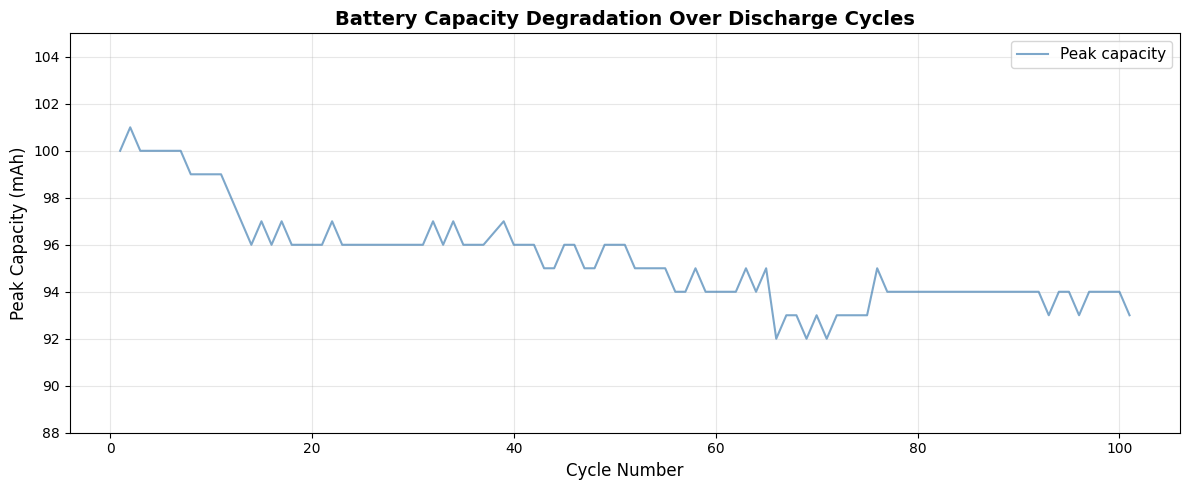

In [135]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(df_cycles['cycle_number'], df_cycles['peak_capacity'],
        color='steelblue', linewidth=1.5, alpha=0.7, label='Peak capacity')

ax.set_xlabel('Cycle Number', fontsize=12)
ax.set_ylabel('Peak Capacity (mAh)', fontsize=12)
ax.set_title('Battery Capacity Degradation Over Discharge Cycles', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_ylim(88, 105)

plt.tight_layout()
plt.show()

Having established a measurable difference between early and late cycle capacities, we now examine whether capacity declines consistently across all cycles. To do this, we compute both the Pearson and Spearman correlations between cycle number and peak discharge capacity. Pearson captures linear relationships, while Spearman detects any monotonic trend, together providing a robust view of capacity decline. 

We also fit a linear regression model to quantify the rate of capacity fade in mAh per cycle and test whether the slope differs from zero. A statistically significant negative slope would indicate that capacity loss is systematic rather than due to random variation.

We formalize this using the following hypotheses:

$$
H_0: \beta = 0
$$

$$
H_1: \beta \neq 0
$$

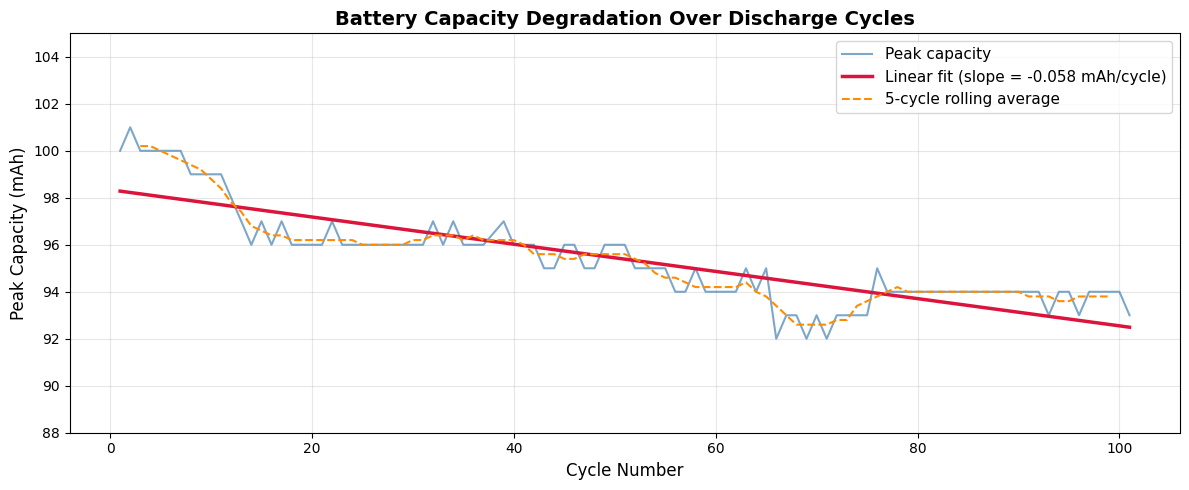

Pearson  r = -0.8525,  p = 2.31e-29
Spearman r = -0.8867,  p = 1.33e-34

Slope:     -0.0579 mAh/cycle
Intercept: 98.3417
R²:        0.7268
p-value:   2.31e-29


In [136]:
#Statistical analysis
pearson_r,  pearson_p  = stats.pearsonr( df_cycles['cycle_number'], df_cycles['peak_capacity'])
spearman_r, spearman_p = stats.spearmanr(df_cycles['cycle_number'], df_cycles['peak_capacity'])

slope, intercept, r, p, se = stats.linregress(
    df_cycles['cycle_number'],
    df_cycles['peak_capacity']
)

x = df_cycles['cycle_number']
y_fit = slope * x + intercept
rolling = df_cycles['peak_capacity'].rolling(window=5, center=True).mean()

# plot
fig, ax = plt.subplots(figsize=(12, 5))

"""ax.scatter(x, df_cycles['peak_capacity'],
           color='steelblue', s=40, alpha=0.7, zorder=3,
           label='Peak capacity per cycle')"""

ax.plot(df_cycles['cycle_number'], df_cycles['peak_capacity'],
        color='steelblue', linewidth=1.5, alpha=0.7, label='Peak capacity')

ax.plot(x, y_fit,
        color='crimson', linewidth=2.5,
        label=f'Linear fit (slope = {slope:.3f} mAh/cycle)')

ax.plot(x, rolling,
        color='darkorange', linewidth=1.5, linestyle='--',
        label='5-cycle rolling average')

ax.set_xlabel('Cycle Number', fontsize=12)
ax.set_ylabel('Peak Capacity (mAh)', fontsize=12)
ax.set_title('Battery Capacity Degradation Over Discharge Cycles', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_ylim(88, 105)

plt.tight_layout()
plt.show()

print(f"Pearson  r = {pearson_r:.4f},  p = {pearson_p:.2e}")
print(f"Spearman r = {spearman_r:.4f},  p = {spearman_p:.2e}")
print(f"\nSlope:     {slope:.4f} mAh/cycle")
print(f"Intercept: {intercept:.4f}")
print(f"R²:        {r**2:.4f}")
print(f"p-value:   {p:.2e}")


The linear regression yields a slope of -0.058 mAh/cycle with a p-value of 2.31e-29, which is astronomically smaller than the 0.05 significance threshold. We therefore reject the null hypothesis with overwhelming confidence and conclude that battery capacity does systematically decline with each discharge cycle. This result is further corroborated by both the Pearson correlation (r = -0.8525, p = 2.31e-29) and Spearman correlation (r = -0.8867, p = 1.33e-34) tests, which independently confirm a strong monotonic negative relationship between cycle number and capacity, ruling out the possibility that the trend is an artifact of the linear regression assumption.

Having established that capacity degrades systematically over cycles, we next test whether the difference between early and late cycle capacities is statistically significant. We divide the data into two groups: the first 20 cycles, representing the battery’s early (healthy) state, and the last 20 cycles, representing its later (degraded) state. We then apply an independent two-sample t-test with the null hypothesis $H_0$ that the mean peak capacity of the two groups is equal, against the alternative hypothesis $H_1$ that the early cycles have a higher mean capacity than the late cycles. A statistically significant result would indicate that the observed decline reflects true degradation rather than random variation.

$$
H_0: \mu_{\text{early}} = \mu_{\text{late}}
$$

$$
H_1: \mu_{\text{early}} > \mu_{\text{late}}
$$

Early 20 — mean: 98.300, std: 1.750, n: 20
Late 20 — mean: 93.864, std: 0.351, n: 22

t-statistic: 11.6477
p-value:     9.94e-15


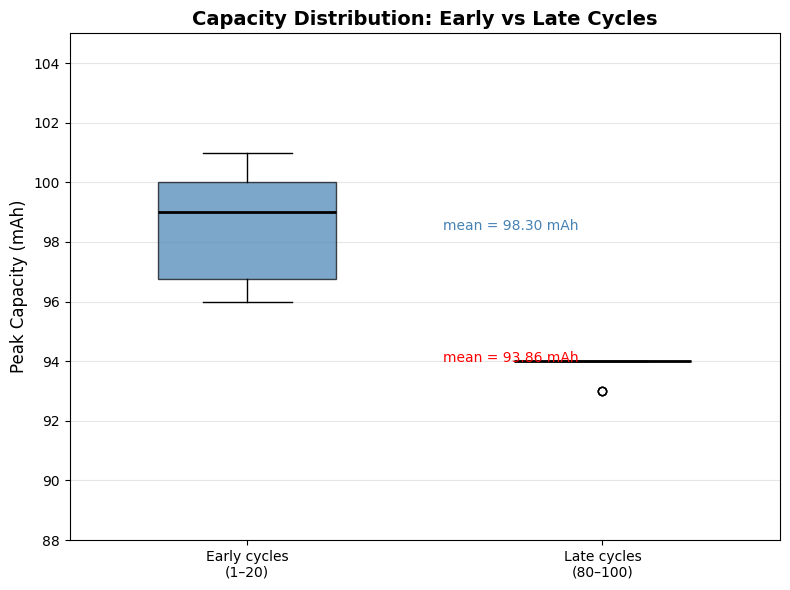

In [137]:
#we split first 20 as early, last 20 as late
early = df_cycles[df_cycles['cycle_number'] <= 20]['peak_capacity']
late  = df_cycles[df_cycles['cycle_number'] >= 80]['peak_capacity']

print(f"Early 20 — mean: {early.mean():.3f}, std: {early.std():.3f}, n: {len(early)}")
print(f"Late 20 — mean: {late.mean():.3f}, std: {late.std():.3f}, n: {len(late)}")

# two simple T test
t_stat, p_val = stats.ttest_ind(early, late, alternative='greater')
print(f"\nt-statistic: {t_stat:.4f}")
print(f"p-value:     {p_val:.2e}")

# plot
fig, ax = plt.subplots(figsize=(8, 6))

bp = ax.boxplot(
    [early, late],
    tick_labels=['Early cycles\n(1–20)', 'Late cycles\n(80–100)'],
    patch_artist=True,
    widths=0.5,
    medianprops=dict(color='black', linewidth=2)
)

bp['boxes'][0].set_facecolor('steelblue')
bp['boxes'][0].set_alpha(0.7)
bp['boxes'][1].set_facecolor('tomato')
bp['boxes'][1].set_alpha(0.7)

ax.annotate(f'mean = {early.mean():.2f} mAh', 
            xy=(1.55, early.mean() + 0.1), fontsize=10, color='steelblue')
ax.annotate(f'mean = {late.mean():.2f} mAh',  
            xy=(1.55, late.mean() + 0.1),  fontsize=10, color='red')

ax.set_ylabel('Peak Capacity (mAh)', fontsize=12)
ax.set_title('Capacity Distribution: Early vs Late Cycles', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(88, 105)

plt.tight_layout()
plt.show()

The two-sample t-test produces a t-statistic of 11.648 and a p-value of 9.94e-15, well below 0.05, so we reject the null hypothesis and conclude that capacity has significantly decreased over time. Early cycles (1–20) have a mean capacity of 98.30 mAh (SD = 1.75), while late cycles (80–100) average 93.86 mAh (SD = 0.35). The lower variability in later cycles suggests the battery stabilizes at a reduced capacity. Overall, the 4.44 mAh drop (~4.5%) reflects a meaningful loss in usable capacity.

To better understand the dataset, we test whether voltage behaves differently during charge and discharge. Physically, this is expected: voltage increases during charging (toward ~4.2V) and decreases during discharging (toward ~3.0V). 

We verify this using the Mann-Whitney U test, which compares two groups without assuming a normal distribution. This helps us check if the difference is statistically meaningful.

We define the hypotheses as:

$$
H_0: \text{Charge and discharge voltages come from the same distribution}
$$

$$
H_1: \text{Charge and discharge voltages come from different distributions}
$$

If we reject $H_0$, it means charge and discharge are truly different states. This confirms that phase is an important feature to include in analysis and modeling.

Charge    — mean: 4.0688 V, std: 0.2056 V, n: 207691
Discharge — mean: 3.6446 V, std: 0.2054 V, n: 147118

Mann-Whitney U statistic: 28739908376.00
p-value:                  0.00e+00


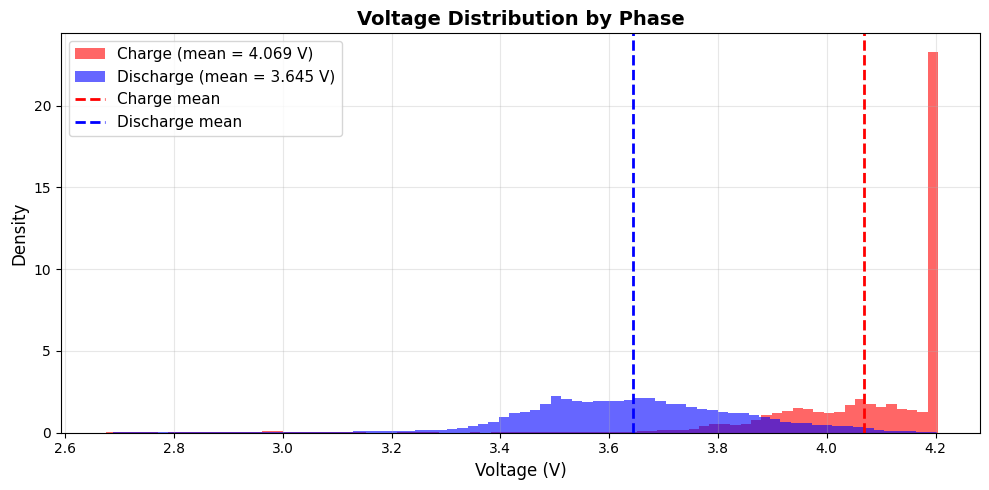

In [138]:
# We remove the rest phrases only keep charge and discharge phases
charge_v    = df[df['phase'] == 'charge']['Voltage_V']
discharge_v = df[df['phase'] == 'discharge']['Voltage_V']

print(f"Charge    — mean: {charge_v.mean():.4f} V, std: {charge_v.std():.4f} V, n: {len(charge_v)}")
print(f"Discharge — mean: {discharge_v.mean():.4f} V, std: {discharge_v.std():.4f} V, n: {len(discharge_v)}")

u_stat, p_val = stats.mannwhitneyu(charge_v, discharge_v, alternative='two-sided')
print(f"\nMann-Whitney U statistic: {u_stat:.2f}")
print(f"p-value:                  {p_val:.2e}")

# ── Plot
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(charge_v,    bins=80, alpha=0.6, color='red',
        density=True, label=f'Charge (mean = {charge_v.mean():.3f} V)')
ax.hist(discharge_v, bins=80, alpha=0.6, color='blue',
        density=True, label=f'Discharge (mean = {discharge_v.mean():.3f} V)')

# Vertical mean lines
ax.axvline(charge_v.mean(), color='red', linestyle='--',
           linewidth=2, label=f'Charge mean')
ax.axvline(discharge_v.mean(), color='blue', linestyle='--',
           linewidth=2, label=f'Discharge mean')

ax.set_xlabel('Voltage (V)', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('Voltage Distribution by Phase', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

The Mann-Whitney U test gives a U-statistic of 28739908376.00 and a p-value near zero (p-value is so small that floating point representation rounds it to zero), well below 0.05. This lets us reject the null hypothesis and conclude that charge and discharge voltages come from different distributions. On average, charge voltage is 4.069 V and discharge voltage is 3.645 V, a difference of 0.424 V. Both phases have similar spreads (~0.206 V), meaning each phase is consistent internally but clearly separate from the other. This makes sense physically: voltage rises toward 4.2 V during charging and falls toward 3.0 V during discharging. For modeling, it confirms that phase is an important feature that captures distinct battery states and should be included in any analysis or predictive model.

Through exploratory analysis and statistical testing, we can summarize three main findings about this battery dataset:

1. **Capacity decline over cycles**  
   Linear regression and correlation show that capacity decreases steadily at about **0.058 mAh per cycle**. Cycle number alone explains **72.7% of the variance** (R² = 0.727), with a highly significant trend (p = 2.31e-29). This confirms that capacity loss is systematic, not random.

2. **Early vs. late cycle capacity**  
   A two-sample t-test shows that the mean capacity of the first 20 cycles (**98.30 mAh**) is significantly higher than the last 20 cycles (**93.86 mAh**; t = 11.648, p = 9.94e-15). This represents a **4.5% drop** in usable capacity over the battery’s recorded lifetime.

3. **Voltage differences by phase**  
   The Mann-Whitney U test confirms that **charge and discharge voltages occupy distinct ranges** (means 4.069 V vs. 3.645 V). This validates that phase is an important feature for modeling, reflecting true electrochemical behavior.